# Data Import

This section is for importing the source data.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/drive/My Drive/Apziva/Project 3 - Potential Talents/potential-talents.csv'

Mounted at /content/drive


In [ ]:
import duckdb

In [ ]:
duckdb_conn = duckdb.connect(database=':memory:', read_only=False)

data = duckdb_conn.sql(f"SELECT * FROM '{data_path}'")

In [ ]:
data.show()

┌───────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────────────────────────────┬────────────┬─────────┐
│  id   │                                                       job_title                                                       │              location               │ connection │   fit   │
│ int64 │                                                        varchar                                                        │               varchar               │  varchar   │ varchar │
├───────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┼─────────────────────────────────────┼────────────┼─────────┤
│     1 │ 2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional              │ Houston, Texas                      │ 85         │ NULL    │
│     2 │ Native English Teacher at EPIK (Eng

'connection' is stored as varchar.

There is no label.

In [ ]:
null_value_check = duckdb_conn.sql("""
SELECT
    SUM(CASE WHEN id IS NULL THEN 1 ELSE 0 END) AS null_id_count,
    SUM(CASE WHEN job_title IS NULL THEN 1 ELSE 0 END) AS null_job_title_count,
    SUM(CASE WHEN location IS NULL THEN 1 ELSE 0 END) AS null_location_count,
    SUM(CASE WHEN connection IS NULL THEN 1 ELSE 0 END) AS null_connection_count
FROM data
""")

print("Null value counts for specified columns:")
null_value_check.show()

Null value counts for specified columns:
┌───────────────┬──────────────────────┬─────────────────────┬───────────────────────┐
│ null_id_count │ null_job_title_count │ null_location_count │ null_connection_count │
│    int128     │        int128        │       int128        │        int128         │
├───────────────┼──────────────────────┼─────────────────────┼───────────────────────┤
│             0 │                    0 │                   0 │                     0 │
└───────────────┴──────────────────────┴─────────────────────┴───────────────────────┘



# Univariate Analysis

In this section, I conduct univariate analysis (analysis of one feature at a time).

The 'Without Data Cleaning' section presents the analysis with raw text data. The initial analysis has indicated that pre-processing is necessary. The 'With Data Cleaning' section shows the refined analysis with pre-processing.

## Without Data Cleaning

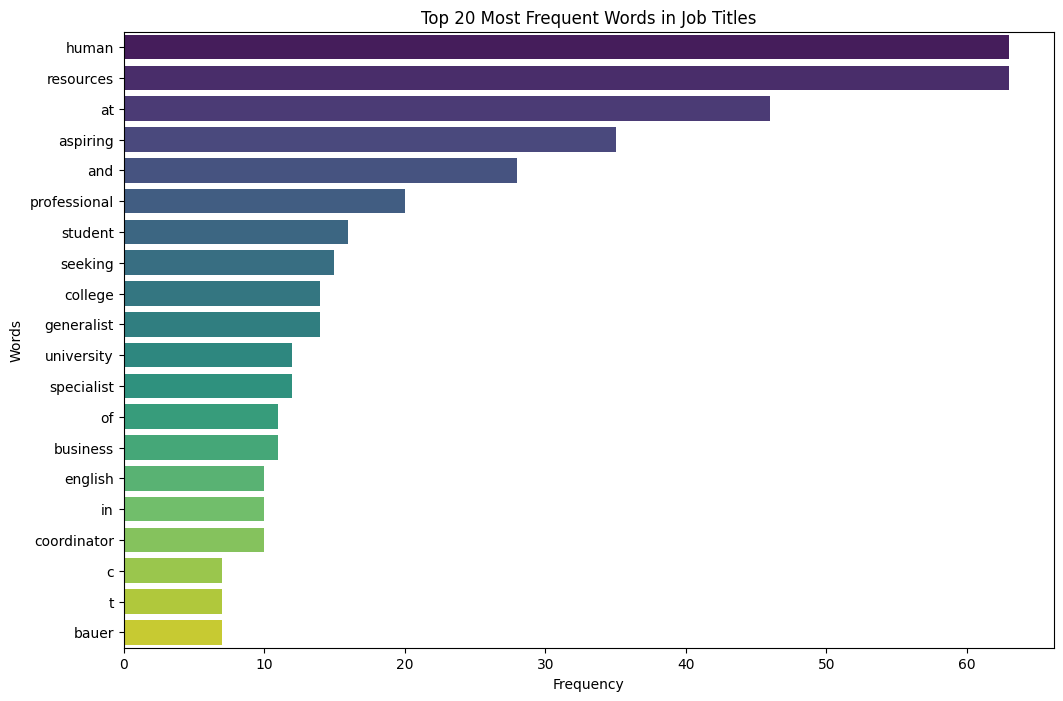

In [ ]:
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch job titles from the DuckDB relation 'data'
# The 'data' variable is assumed to be a DuckDB relation.
# Use .project('column_name') to select a column and .fetchall() to get the results as a list of tuples.
job_titles_list = [row[0] for row in data.project('job_title').fetchall()]

# Combine all job titles into a single string
all_job_titles = ' '.join(job_titles_list)

# Convert to lowercase
all_job_titles = all_job_titles.lower()

# Tokenize words and remove non-alphabetic characters
words = re.findall(r'\b[a-z]+\b', all_job_titles)

# Count word frequencies
word_counts = Counter(words)

# Get the most common words for the histogram
top_words = word_counts.most_common(20)

# Extract words and counts into separate lists for seaborn
plot_words = [item[0] for item in top_words]
plot_counts = [item[1] for item in top_words]

# Create the histogram
plt.figure(figsize=(12, 8))
# Use lists directly for x and y, as seaborn barplot can accept them.
sns.barplot(x=plot_counts, y=plot_words, palette='viridis', hue=plot_words, legend=False)
plt.title('Top 20 Most Frequent Words in Job Titles')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

In the job title text field, I'm noticing stopwords like 'the', 'a', etc.

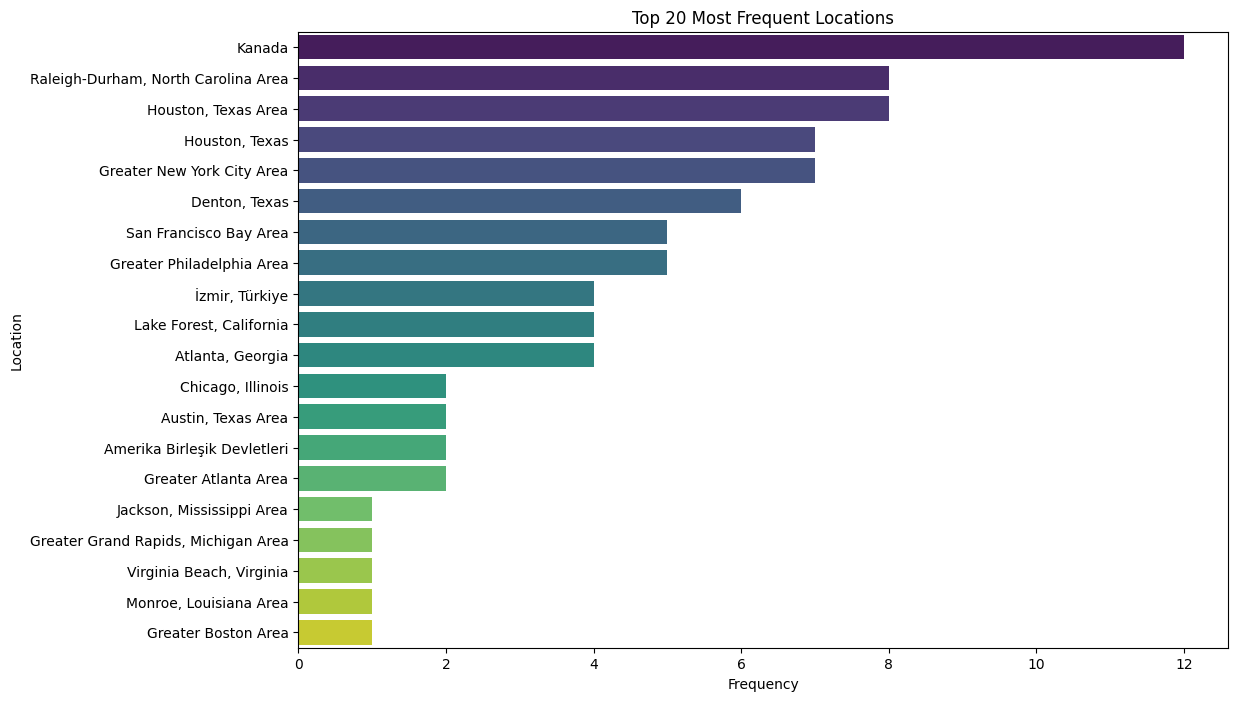

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch locations from the DuckDB relation 'data'
location_list = [row[0] for row in data.project('location').fetchall()]

# Count word frequencies
location_counts_counter = Counter(location_list)

# Get the most common locations for the histogram
top_locations = location_counts_counter.most_common(20)

# Extract locations and counts into separate lists for seaborn
plot_locations = [item[0] for item in top_locations]
plot_location_counts = [item[1] for item in top_locations]

# Create the histogram
plt.figure(figsize=(12, 8))
sns.barplot(x=plot_location_counts, y=plot_locations, palette='viridis', hue=plot_locations, legend=False)
plt.title('Top 20 Most Frequent Locations')
plt.xlabel('Frequency')
plt.ylabel('Location')
plt.show()

I'm noticing that semantically identical entries (e.g., 'Greater New York City Area' and 'New York, New York') are being treated as distinct values.

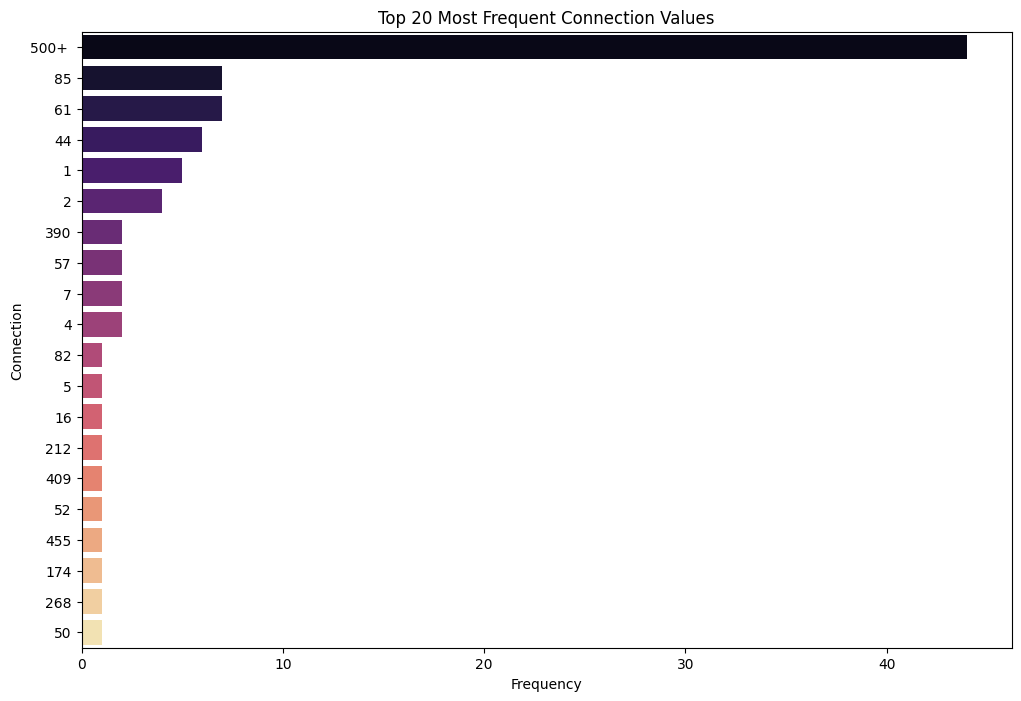

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch connection values from the DuckDB relation 'data'
connection_list = [row[0] for row in data.project('connection').fetchall()]

# Count frequencies of connection values
connection_counts_counter = Counter(connection_list)

# Get the most common connection values for the histogram
top_connections = connection_counts_counter.most_common(20)

# Extract connection values and counts into separate lists for seaborn
plot_connections = [item[0] for item in top_connections]
plot_connection_counts = [item[1] for item in top_connections]

# Create the histogram
plt.figure(figsize=(12, 8))
sns.barplot(x=plot_connection_counts, y=plot_connections, palette='magma', hue=plot_connections, legend=False)
plt.title('Top 20 Most Frequent Connection Values')
plt.xlabel('Frequency')
plt.ylabel('Connection')
plt.show()

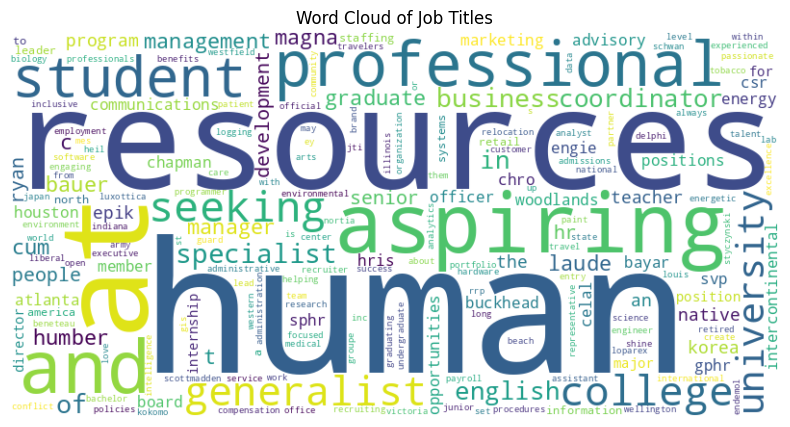

In [ ]:
from wordcloud import WordCloud
from collections import Counter
import re
import matplotlib.pyplot as plt

# Fetch job titles from the DuckDB relation 'data'
job_titles_raw = [row[0] for row in data.project('job_title').fetchall()]

# Combine all job titles into a single string and convert to lowercase
all_job_titles_concatenated = ' '.join(job_titles_raw).lower()

# Tokenize words (no text processing or stopwords removal)
word_counts_for_wc = Counter(re.findall(r'\b[a-z]+\b', all_job_titles_concatenated))

# Create the WordCloud object and fit it with the word frequencies
job_tile_wc = WordCloud(width=800, height=400, background_color='white')
job_tile_wc.fit_words(word_counts_for_wc)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(job_tile_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Job Titles')
plt.show()

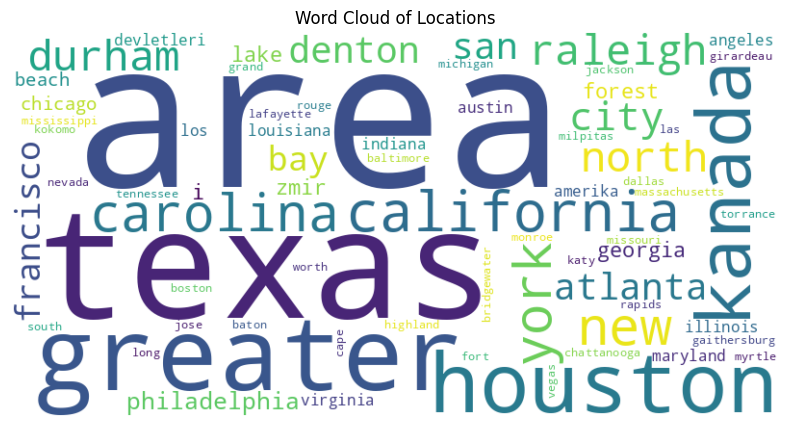

In [ ]:
from wordcloud import WordCloud
from collections import Counter
import re
import matplotlib.pyplot as plt

# Fetch locations from the DuckDB relation 'data'
locations_raw = [row[0] for row in data.project('location').fetchall()]

# Combine all locations into a single string and convert to lowercase
all_locations_concatenated = ' '.join(locations_raw).lower()

# Tokenize words (no text processing or stopwords removal)
word_counts_for_location_wc = Counter(re.findall(r'\b[a-z]+\b', all_locations_concatenated))

# Create the WordCloud object and fit it with the word frequencies
location_wc = WordCloud(width=800, height=400, background_color='white')
location_wc.fit_words(word_counts_for_location_wc)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(location_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Locations')
plt.show()

I'm noticing that the word cloud generator is splitting compound words into individual words. For example, 'cum laude' is being broken down into 'cum' and 'laude' rather than being treated as a single entity.

For the location text, it would be reasonable to remove 'area'.

## With Data Cleaning

Text Data Cleaning
- remove stop words like 'the' or 'a'

- handle semantically identical words / phrases
  - fuzzy matching

- handle compound words
  - n-grams

- fix any potential typos

further text analysis
- natural language processing tasks
- keyword extraction
- feature engineering for machine learning models


In [ ]:
import nltk
import string

# Download the 'stopwords' corpus if not already downloaded
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

# Get the list of English stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize words and remove stopwords
    words = [word for word in text.split() if word not in stop_words]

    # Join the words back into a string
    return ' '.join(words)

In [ ]:
import duckdb.typing

try:
    # Register the Python function as a DuckDB UDF
    duckdb_conn.create_function("clean_text_udf", clean_text, return_type=duckdb.typing.VARCHAR, parameters=[duckdb.typing.VARCHAR])
except duckdb.NotImplementedException as e:
    if "A function by the name of 'clean_text_udf' is already created" in str(e):
        print("UDF 'clean_text_udf' already exists. Skipping creation.")
    else:
        raise # Re-raise other NotImplementedExceptions

# Apply the UDF to 'job_title' and 'location' columns and create a new DuckDB relation
data = duckdb_conn.sql("""
SELECT
    *, -- Select all existing columns
    clean_text_udf(job_title) AS cleaned_job_title,
    clean_text_udf(location) AS cleaned_location
FROM data
""")

print("Cleaning applied to 'job_title' and 'location' columns. The 'data' relation has been updated.")
print("New 'data' relation head with cleaned columns:")
data.show()

Cleaning applied to 'job_title' and 'location' columns. The 'data' relation has been updated.
New 'data' relation head with cleaned columns:
┌───────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬─────────────────────────────────────┬────────────┬─────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────┬───────────────────────────────────┐
│  id   │                                                       job_title                                                       │              location               │ connection │   fit   │                                             cleaned_job_title                                             │         cleaned_location          │
│ int64 │                                                        varchar                                                        │               varchar               │  varchar   │ varchar 

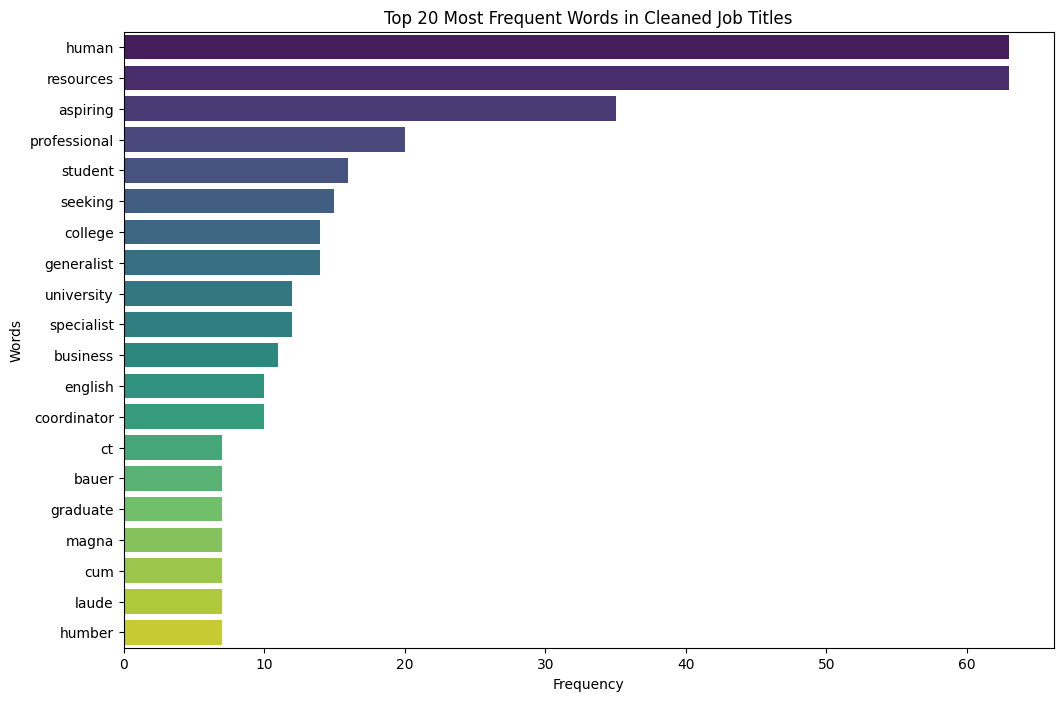

In [ ]:
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch cleaned job titles from the DuckDB relation 'data'
cleaned_job_titles_list = [row[0] for row in data.project('cleaned_job_title').fetchall()]

# Combine all cleaned job titles into a single string
all_cleaned_job_titles = ' '.join(cleaned_job_titles_list)

# Tokenize words (already lowercased and punctuation/stopwords removed)
cleaned_words = re.findall(r'\b[a-z]+\b', all_cleaned_job_titles)

# Count word frequencies
cleaned_word_counts = Counter(cleaned_words)

# Get the most common words for the histogram
top_cleaned_words = cleaned_word_counts.most_common(20)

# Prepare data for plotting
plot_cleaned_words = [item[0] for item in top_cleaned_words]
plot_cleaned_counts = [item[1] for item in top_cleaned_words]

# Create the histogram
plt.figure(figsize=(12, 8))
sns.barplot(x=plot_cleaned_counts, y=plot_cleaned_words, palette='viridis', hue=plot_cleaned_words, legend=False)
plt.title('Top 20 Most Frequent Words in Cleaned Job Titles')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

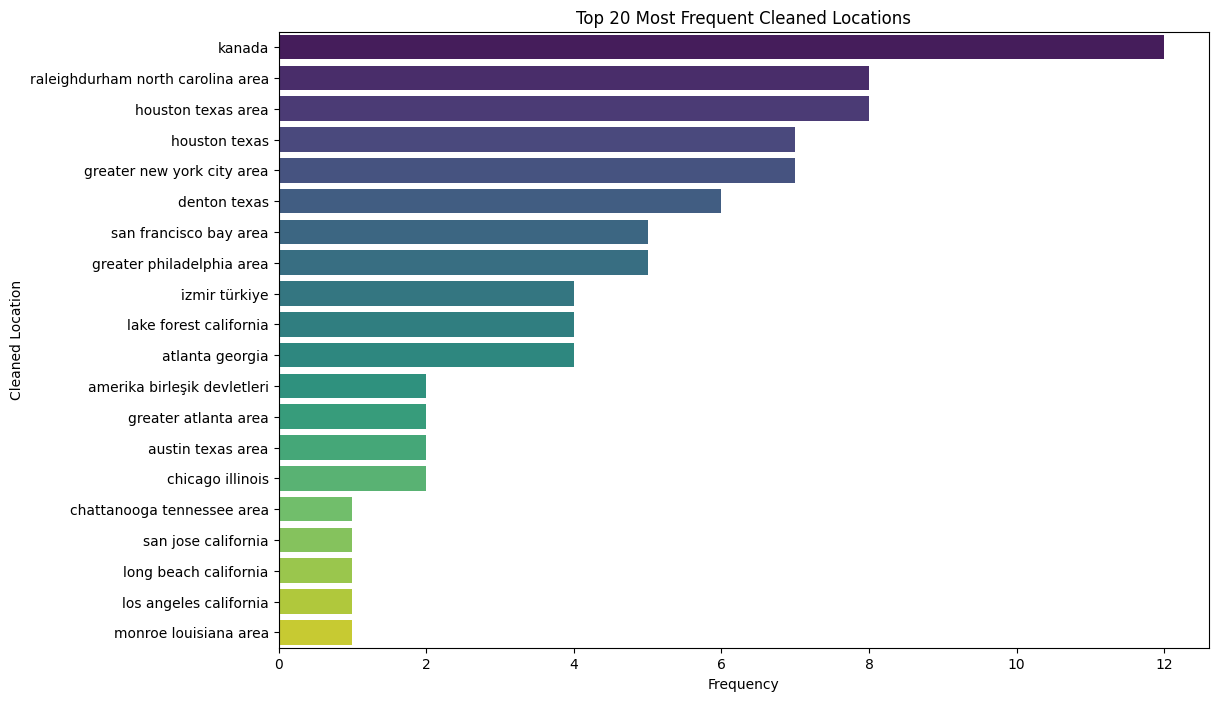

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb

# Fetch top 20 most frequent cleaned locations directly from DuckDB
top_cleaned_locations_query = duckdb_conn.sql("""
    SELECT cleaned_location, COUNT(*) AS count
    FROM data
    GROUP BY cleaned_location
    ORDER BY count DESC
    LIMIT 20
""").fetchall()

# Extract locations and counts into separate lists for plotting
plot_cleaned_locations = [row[0] for row in top_cleaned_locations_query]
plot_cleaned_location_counts = [row[1] for row in top_cleaned_locations_query]

# Create the histogram
plt.figure(figsize=(12, 8))
sns.barplot(x=plot_cleaned_location_counts, y=plot_cleaned_locations, palette='viridis', hue=plot_cleaned_locations, legend=False)
plt.title('Top 20 Most Frequent Cleaned Locations')
plt.xlabel('Frequency')
plt.ylabel('Cleaned Location')
plt.show()

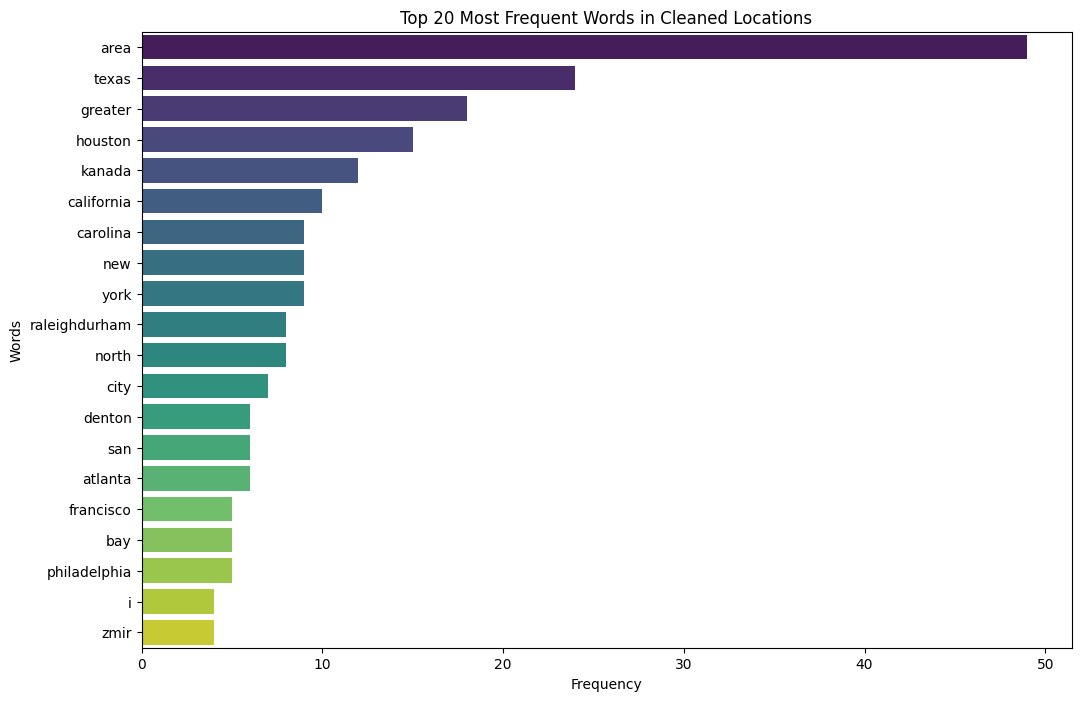

In [ ]:
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Fetch cleaned locations from the DuckDB relation 'data'
cleaned_locations_list = [row[0] for row in data.project('cleaned_location').fetchall()]

# Combine all cleaned locations into a single string
all_cleaned_locations = ' '.join(cleaned_locations_list)

# Tokenize words (already lowercased and punctuation/stopwords removed)
cleaned_location_words = re.findall(r'\b[a-z]+\b', all_cleaned_locations)

# Count word frequencies
cleaned_location_word_counts = Counter(cleaned_location_words)

# Get the most common words for the histogram
top_cleaned_location_words = cleaned_location_word_counts.most_common(20)

# Prepare data for plotting
plot_cleaned_location_words = [item[0] for item in top_cleaned_location_words]
plot_cleaned_location_counts = [item[1] for item in top_cleaned_location_words]

# Create the histogram
plt.figure(figsize=(12, 8))
sns.barplot(x=plot_cleaned_location_counts, y=plot_cleaned_location_words, palette='viridis', hue=plot_cleaned_location_words, legend=False)
plt.title('Top 20 Most Frequent Words in Cleaned Locations')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()

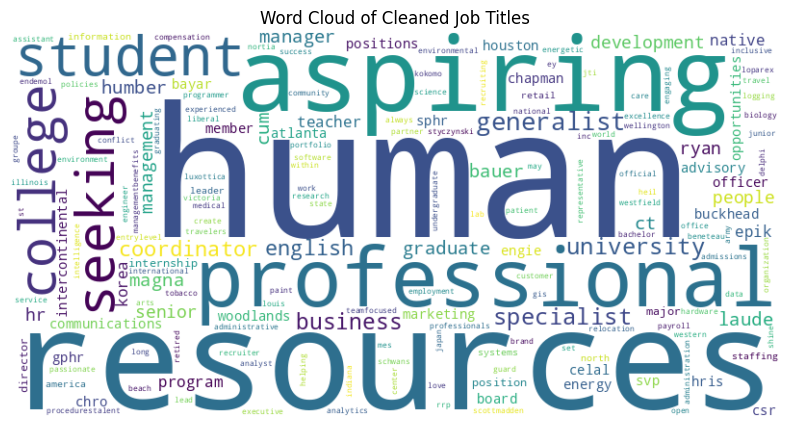

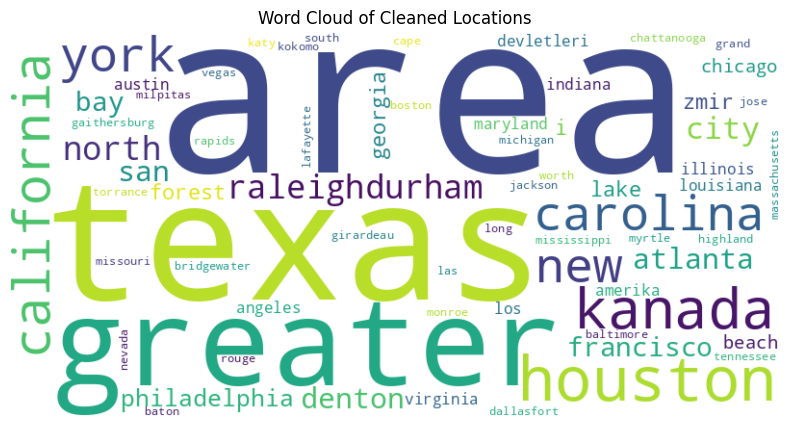

In [ ]:
from wordcloud import WordCloud
from collections import Counter
import re
import matplotlib.pyplot as plt

# --- Word Cloud for Cleaned Job Titles ---
# Fetch cleaned job titles from the DuckDB relation 'data'
cleaned_job_titles_list_wc = [row[0] for row in data.project('cleaned_job_title').fetchall()]

# Combine all cleaned job titles into a single string
all_cleaned_job_titles_wc = ' '.join(cleaned_job_titles_list_wc)

# Tokenize words (already lowercased and punctuation/stopwords removed)
cleaned_words_wc = re.findall(r'\b[a-z]+\b', all_cleaned_job_titles_wc)

# Count word frequencies
cleaned_word_counts_wc = Counter(cleaned_words_wc)

# Create the WordCloud object and fit it with the word frequencies
cleaned_job_title_wc = WordCloud(width=800, height=400, background_color='white')
cleaned_job_title_wc.fit_words(cleaned_word_counts_wc)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(cleaned_job_title_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Job Titles')
plt.show()

# --- Word Cloud for Cleaned Locations ---
# Fetch cleaned locations from the DuckDB relation 'data'
cleaned_locations_list_wc = [row[0] for row in data.project('cleaned_location').fetchall()]

# Combine all cleaned locations into a single string
all_cleaned_locations_wc = ' '.join(cleaned_locations_list_wc)

# Tokenize words (already lowercased and punctuation/stopwords removed)
cleaned_location_words_wc = re.findall(r'\b[a-z]+\b', all_cleaned_locations_wc)

# Count word frequencies
cleaned_location_word_counts_wc = Counter(cleaned_location_words_wc)

# Create the WordCloud object and fit it with the word frequencies
cleaned_location_wc = WordCloud(width=800, height=400, background_color='white')
cleaned_location_wc.fit_words(cleaned_location_word_counts_wc)

# Display the generated image:
plt.figure(figsize=(10, 5))
plt.imshow(cleaned_location_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Cleaned Locations')
plt.show()

### Potential Areas of Improvement:
* **Term Refinement**: Remove geographically irrelevant terms like 'area' from the location data.
* **Acronym Expansion**: Map acronyms to their full descriptive terms for better semantic matching.
* **Morphological Processing**: Implement stemming or lemmatization to normalize verb forms and word variations.

# Bivariate Analysis

In this section, I conduct bivariate analysis (analysis of two features at a time).

## Job Title and Location

In [ ]:
import re

# 1. Extract words from top_cleaned_words
top_job_title_words = [word for word, count in top_cleaned_words]

# 2. Extract words from top_cleaned_location_words
top_location_words = [word for word, count in top_cleaned_location_words]

print("Top 20 Job Title Words:")
print(top_job_title_words)
print("\nTop 20 Location Words:")
print(top_location_words)

Top 20 Job Title Words:
['human', 'resources', 'aspiring', 'professional', 'student', 'seeking', 'college', 'generalist', 'university', 'specialist', 'business', 'english', 'coordinator', 'ct', 'bauer', 'graduate', 'magna', 'cum', 'laude', 'humber']

Top 20 Location Words:
['area', 'texas', 'greater', 'houston', 'kanada', 'california', 'carolina', 'new', 'york', 'raleighdurham', 'north', 'city', 'denton', 'san', 'atlanta', 'francisco', 'bay', 'philadelphia', 'i', 'zmir']


In [ ]:
# Prepare the SQL VALUES clause for top_job_title_words
job_words_sql_values = ", ".join([f"('{word.replace("'", "''")}')" for word in top_job_title_words])

# Prepare the SQL VALUES clause for top_location_words
location_words_sql_values = ", ".join([f"('{word.replace("'", "''")}')" for word in top_location_words])

# Construct the DuckDB query for 2-way word co-occurrence
# This query efficiently checks for the presence of each top word (as a whole word)
# within the cleaned job title and location fields for each record,
# then groups and counts the co-occurrences directly within DuckDB.
word_co_occurrence_query_duckdb = f"""
WITH TopJobWords AS (
    SELECT word FROM (VALUES {job_words_sql_values}) AS t(word)
),
TopLocationWords AS (
    SELECT word FROM (VALUES {location_words_sql_values}) AS t(word)
)
SELECT
    tj.word AS job_title_word,
    tl.word AS location_word,
    COUNT(d.id) AS co_occurrence_count
FROM
    data AS d
CROSS JOIN
    TopJobWords AS tj
CROSS JOIN
    TopLocationWords AS tl
WHERE
    -- Check if the cleaned_job_title contains the job_word as a whole word
    regexp_matches(d.cleaned_job_title, '\\b' || tj.word || '\\b') AND
    -- Check if the cleaned_location contains the location_word as a whole word
    regexp_matches(d.cleaned_location, '\\b' || tl.word || '\\b')
GROUP BY
    tj.word,
    tl.word
ORDER BY
    co_occurrence_count DESC;
"""

# Execute the query and fetch into a pandas DataFrame
word_co_occurrence_df = duckdb_conn.sql(word_co_occurrence_query_duckdb).fetchdf()

print("Head of Word Co-occurrence DataFrame (Job Title Word vs. Location Word) using DuckDB:")
print(word_co_occurrence_df.head())

Head of Word Co-occurrence DataFrame (Job Title Word vs. Location Word) using DuckDB:
  job_title_word location_word  co_occurrence_count
0          human          area                   33
1      resources          area                   33
2       aspiring          area                   19
3          human       greater                   13
4      resources       greater                   13


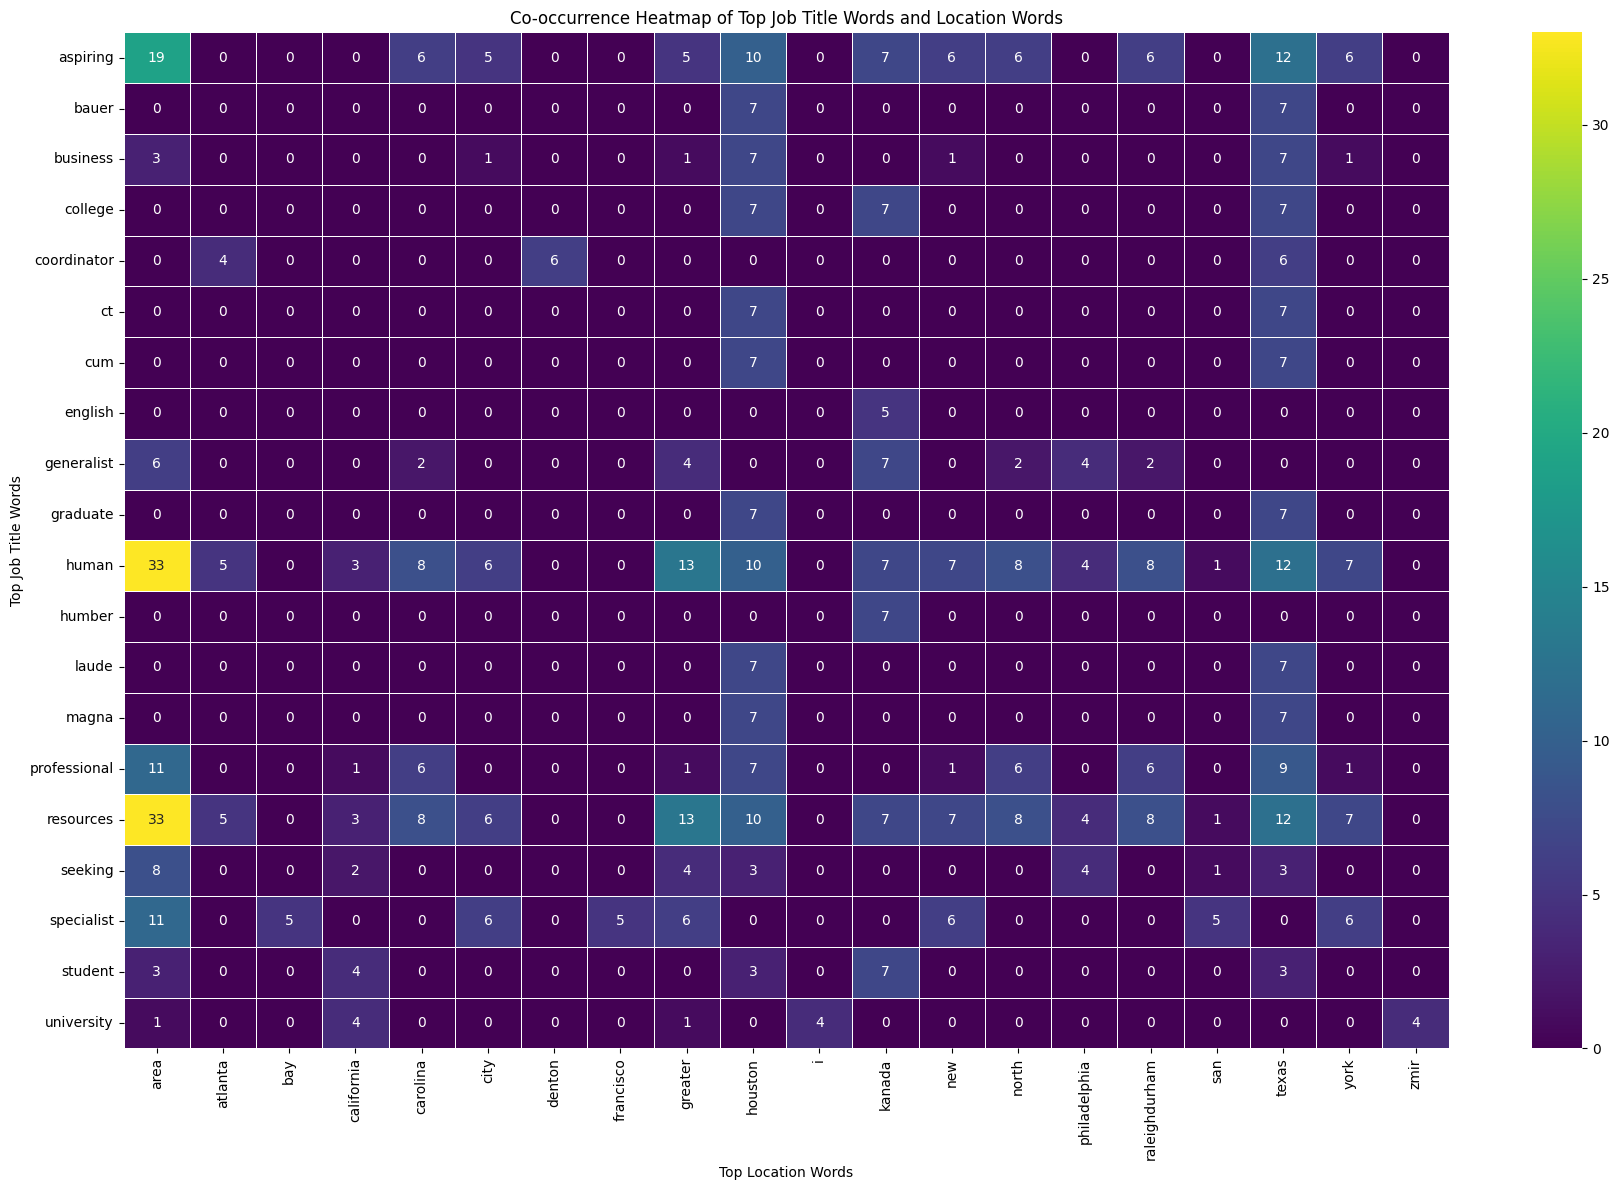

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pivot the DataFrame to create a matrix for the heatmap
# Rows: job_title_word, Columns: location_word, Values: co_occurrence_count
heatmap_data_word_co = word_co_occurrence_df.pivot_table(
    index='job_title_word',
    columns='location_word',
    values='co_occurrence_count'
).fillna(0) # Fill non-co-occurring pairs with 0

# Create the heatmap
plt.figure(figsize=(18, 12)) # Adjust figure size for better readability
sns.heatmap(
    heatmap_data_word_co,
    annot=True, # Show the co-occurrence counts on the heatmap
    fmt='g',    # Format annotations as general number
    cmap='viridis', # Color map for the heatmap
    linewidths=.5 # Add lines between cells
)
plt.title('Co-occurrence Heatmap of Top Job Title Words and Location Words')
plt.xlabel('Top Location Words')
plt.ylabel('Top Job Title Words')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Job Title and Connection

In [ ]:
# Prepare the SQL VALUES clause for top_job_title_words
job_words_sql_values_for_co = ", ".join([f"('{word.replace("'", "''")}')" for word in top_job_title_words])

# Prepare the SQL VALUES clause for top_connections
# Correctly extract only the connection string (first element of the tuple) and quote it
connection_values_sql_values_for_co = ", ".join([f"'{conn[0].replace("'", "''").strip()}'" for conn in top_connections])

# Construct the DuckDB query for word (job_title) and connection co-occurrence
word_connection_co_occurrence_query = f"""
WITH TopJobTitleWords AS (
    SELECT word FROM (VALUES {job_words_sql_values_for_co}) AS t(word)
)
SELECT
    tjw.word AS job_title_word,
    TRIM(d.connection) AS connection,
    COUNT(d.id) AS co_occurrence_count
FROM
    data AS d
CROSS JOIN
    TopJobTitleWords AS tjw
WHERE
    -- Check if the cleaned_job_title contains the job_title_word as a whole word
    regexp_matches(d.cleaned_job_title, '\\b' || tjw.word || '\\b') AND
    TRIM(d.connection) IN ({connection_values_sql_values_for_co}) -- Also trim for IN clause consistency
GROUP BY
    tjw.word,
    d.connection
ORDER BY
    co_occurrence_count DESC;
"""

# Execute the query and fetch into a pandas DataFrame
word_connection_co_occurrence_df = duckdb_conn.sql(word_connection_co_occurrence_query).fetchdf()

print("Head of Word Co-occurrence DataFrame (Job Title Word vs. Connection Value) using DuckDB:")
print(word_connection_co_occurrence_df.head())

Head of Word Co-occurrence DataFrame (Job Title Word vs. Connection Value) using DuckDB:
  job_title_word connection  co_occurrence_count
0          human       500+                   17
1      resources       500+                   17
2    coordinator       500+                   10
3      resources         85                    7
4      resources         61                    7


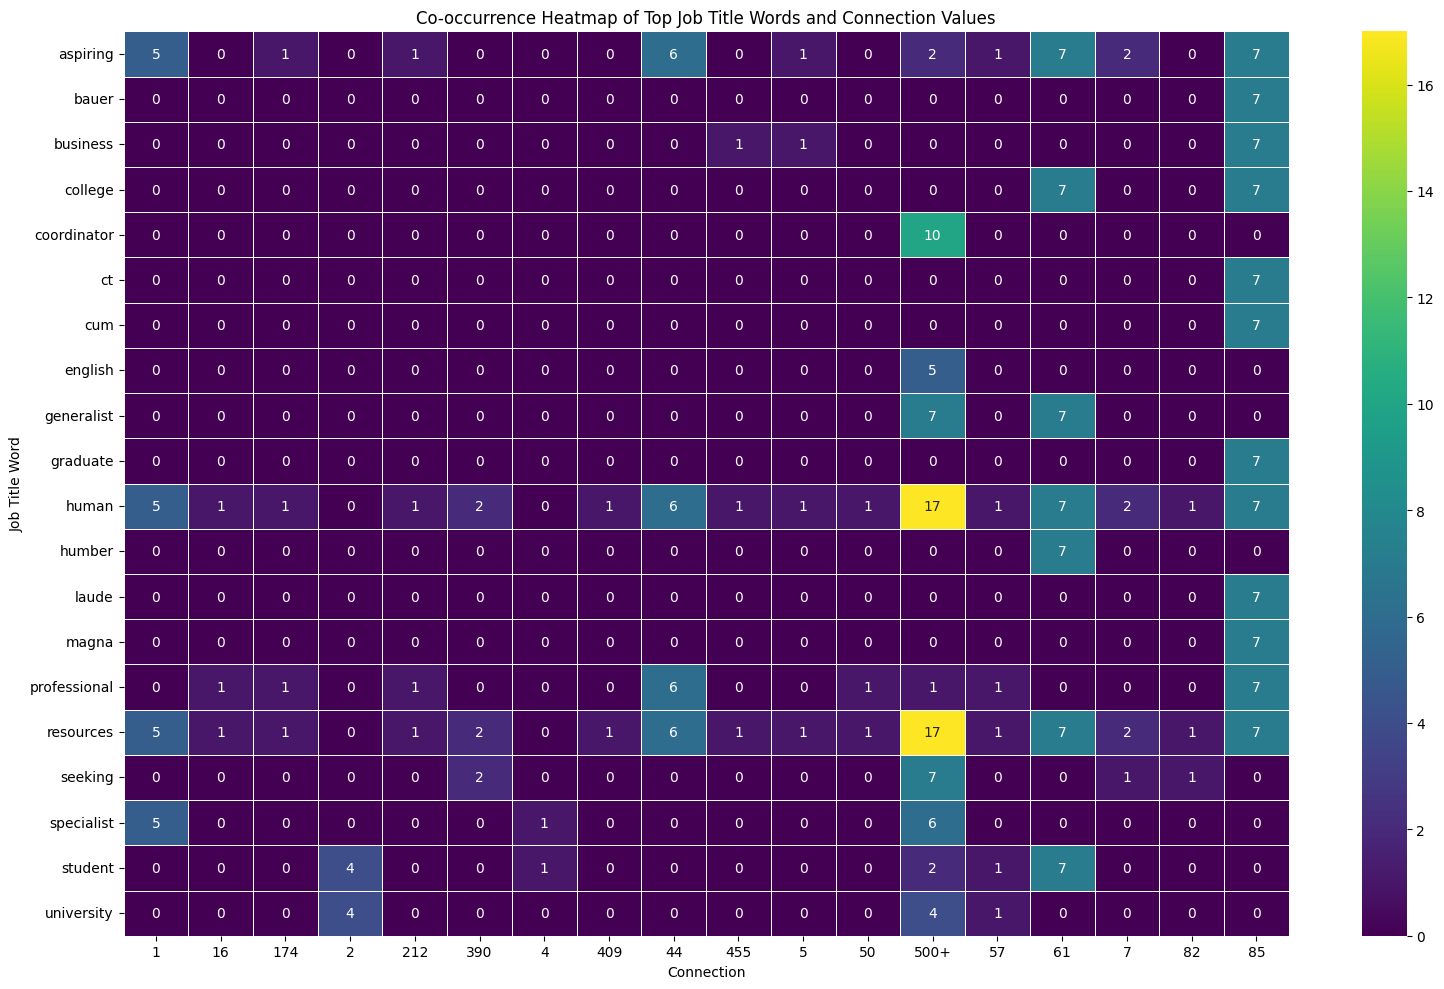

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pivot the DataFrame to create a matrix for the heatmap
# Rows: job_title_word, Columns: connection, Values: co_occurrence_count
heatmap_data_word_connection = word_connection_co_occurrence_df.pivot_table(
    index='job_title_word',
    columns='connection',
    values='co_occurrence_count'
).fillna(0) # Fill non-co-occurring pairs with 0

# Create the heatmap
plt.figure(figsize=(16, 10)) # Adjust figure size for better readability
sns.heatmap(
    heatmap_data_word_connection,
    annot=True, # Show the co-occurrence counts on the heatmap
    fmt='g',    # Format annotations as general number
    cmap='viridis', # Color map for the heatmap
    linewidths=.5 # Add lines between cells
)
plt.title('Co-occurrence Heatmap of Top Job Title Words and Connection Values')
plt.xlabel('Connection')
plt.ylabel('Job Title Word')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Location and Connection

In [ ]:
word_co_occurrence_query_duckdb_trimmed = f"""
WITH TopLocationWords AS (
    SELECT word FROM (VALUES {location_words_sql_values}) AS t(word)
)
SELECT
    tl.word AS location_word,
    TRIM(d.connection) AS connection, -- Apply TRIM here
    COUNT(d.id) AS co_occurrence_count
FROM
    data AS d
CROSS JOIN
    TopLocationWords AS tl
WHERE
    -- Check if the cleaned_location contains the location_word as a whole word
    regexp_matches(d.cleaned_location, '\\b' || tl.word || '\\b') AND
    TRIM(d.connection) IN ({connection_values_sql_values_for_co}) -- Also trim for IN clause consistency
GROUP BY
    tl.word,
    TRIM(d.connection) -- Apply TRIM here
ORDER BY
    co_occurrence_count DESC;
"""

# Execute the modified query and fetch into a pandas DataFrame
location_connection_co_occurrence_df = duckdb_conn.sql(word_co_occurrence_query_duckdb_trimmed).fetchdf()

print("Head of Word Co-occurrence DataFrame (Location Word vs. Trimmed Connection Value) using DuckDB:")
print(location_connection_co_occurrence_df.head())

Head of Word Co-occurrence DataFrame (Location Word vs. Trimmed Connection Value) using DuckDB:
  location_word connection  co_occurrence_count
0          area       500+                   22
1         texas       500+                   13
2       greater       500+                    8
3         texas         85                    7
4       houston         85                    7


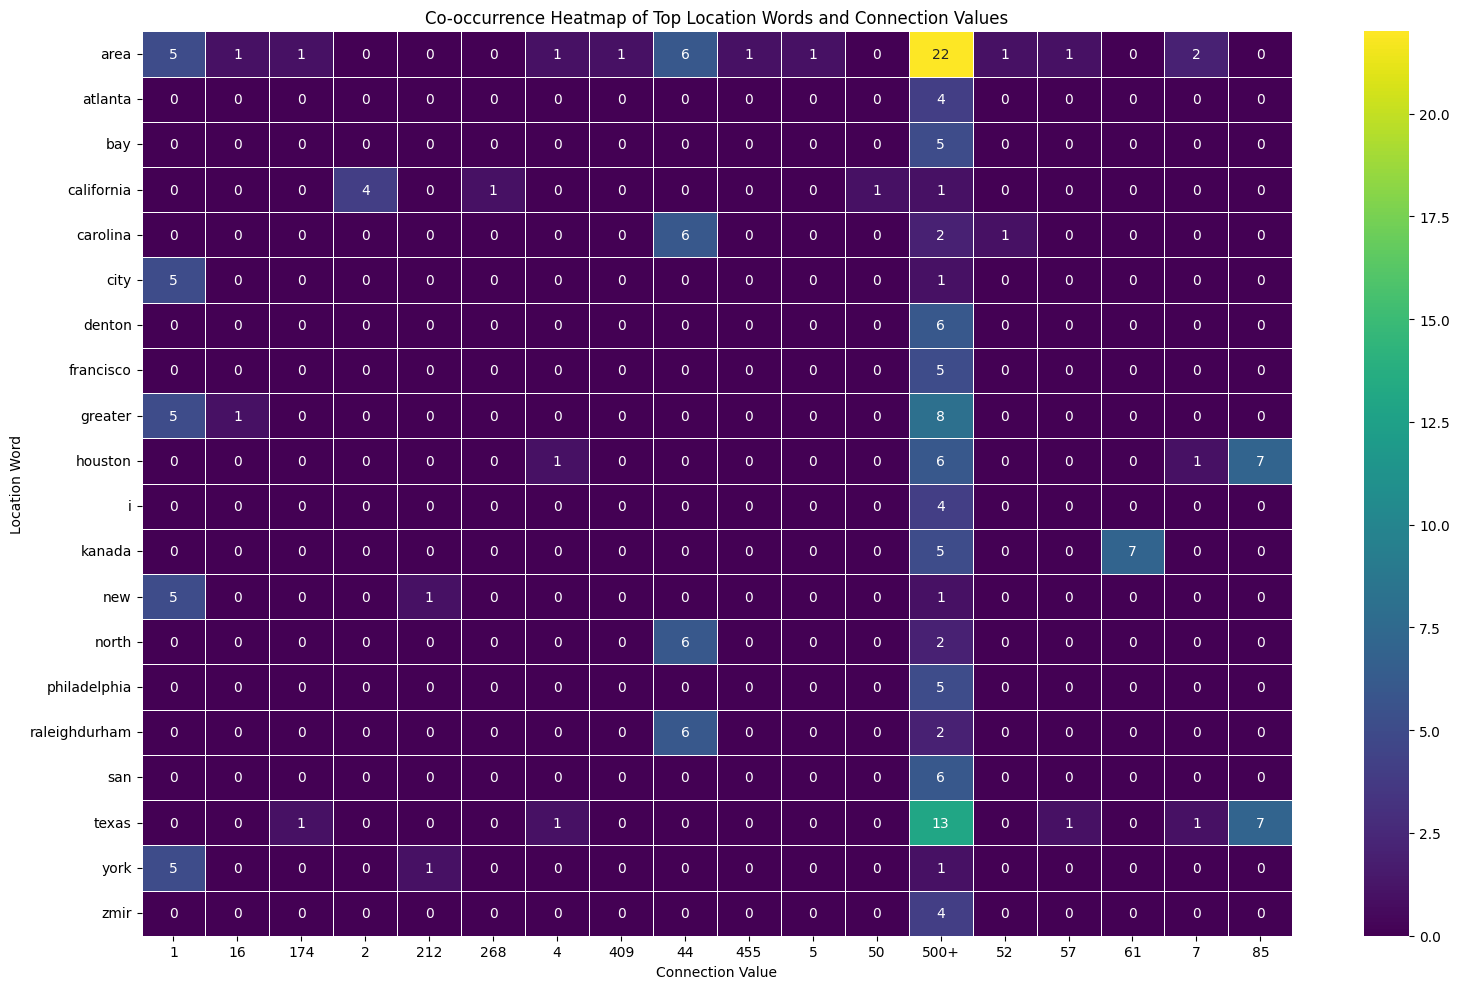

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pivot the DataFrame to create a matrix for the heatmap
# Rows: cleaned_location_advanced, Columns: cleaned_connection, Values: co_occurrence_count
heatmap_data_location_connection = location_connection_co_occurrence_df.pivot_table(
    index='location_word',
    columns='connection',
    values='co_occurrence_count'
).fillna(0) # Fill non-co-occurring pairs with 0

# Create the heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(
    heatmap_data_location_connection,
    annot=True, # Show the co-occurrence counts on the heatmap
    fmt='g',    # Format annotations as general number
    cmap='viridis', # Color map for the heatmap
    linewidths=.5 # Add lines between cells
)
plt.title('Co-occurrence Heatmap of Top Location Words and Connection Values')
plt.xlabel('Connection Value')
plt.ylabel('Location Word')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Multivariate Analysis

In this section, I conduct multivariate analysis to find the 3-way relationship of the Job title, Location, and Connection features.

In [ ]:
top_job_title_words_for_3way = [item[0] for item in top_cleaned_words]
top_cleaned_locations_for_3way = plot_cleaned_locations
top_connection_values_for_3way = [item[0] for item in top_connections]

job_words_sql_values_3way = ", ".join([f"('{word.replace("'", "''")}')" for word in top_job_title_words_for_3way])
location_values_sql_3way = ", ".join([f"('{loc.replace("'", "''")}')" for loc in top_cleaned_locations_for_3way])
connection_values_sql_3way = ", ".join([f"('{conn.replace("'", "''")}')" for conn in top_connection_values_for_3way])

print("Generated SQL VALUES clause for job title words:")
print(job_words_sql_values_3way)
print("\nGenerated SQL VALUES clause for cleaned location entries:")
print(location_values_sql_3way)
print("\nGenerated SQL VALUES clause for connection values:")
print(connection_values_sql_3way)

Generated SQL VALUES clause for job title words:
('human'), ('resources'), ('aspiring'), ('professional'), ('student'), ('seeking'), ('college'), ('generalist'), ('university'), ('specialist'), ('business'), ('english'), ('coordinator'), ('ct'), ('bauer'), ('graduate'), ('magna'), ('cum'), ('laude'), ('humber')

Generated SQL VALUES clause for cleaned location entries:
('kanada'), ('houston texas area'), ('raleighdurham north carolina area'), ('greater new york city area'), ('houston texas'), ('denton texas'), ('greater philadelphia area'), ('san francisco bay area'), ('lake forest california'), ('atlanta georgia'), ('i̇zmir türkiye'), ('chicago illinois'), ('greater atlanta area'), ('austin texas area'), ('amerika birleşik devletleri'), ('long beach california'), ('kokomo indiana area'), ('cape girardeau missouri'), ('lafayette indiana'), ('bridgewater massachusetts')

Generated SQL VALUES clause for connection values:
('500+ '), ('85'), ('61'), ('44'), ('1'), ('2'), ('390'), ('57'), 

In [ ]:
co_occurrence_3way_query = f"""
SELECT
    tjw.word AS job_title_word,
    tcl.location AS cleaned_location,
    d.connection,
    COUNT(d.id) AS co_occurrence_count
FROM
    data AS d
CROSS JOIN
    (SELECT word FROM (VALUES {job_words_sql_values_3way}) AS t(word)) AS tjw
CROSS JOIN
    (SELECT location FROM (VALUES {location_values_sql_3way}) AS t(location)) AS tcl
WHERE
    regexp_matches(d.cleaned_job_title, '\\b' || tjw.word || '\\b') AND
    d.cleaned_location = tcl.location AND
    d.connection IN ({connection_values_sql_3way})
GROUP BY
    tjw.word,
    tcl.location,
    d.connection
ORDER BY
    co_occurrence_count DESC;
"""

# Execute the query and fetch into a pandas DataFrame
co_occurrence_3way_df = duckdb_conn.sql(co_occurrence_3way_query).fetchdf()

print("Head of 3-Way Co-occurrence DataFrame (Job Title Word, Cleaned Location, Connection) using DuckDB:")
print(co_occurrence_3way_df.head())

Head of 3-Way Co-occurrence DataFrame (Job Title Word, Cleaned Location, Connection) using DuckDB:
  job_title_word cleaned_location connection  co_occurrence_count
0          human           kanada         61                    7
1      resources    houston texas         85                    7
2        student           kanada         61                    7
3             ct    houston texas         85                    7
4       graduate    houston texas         85                    7


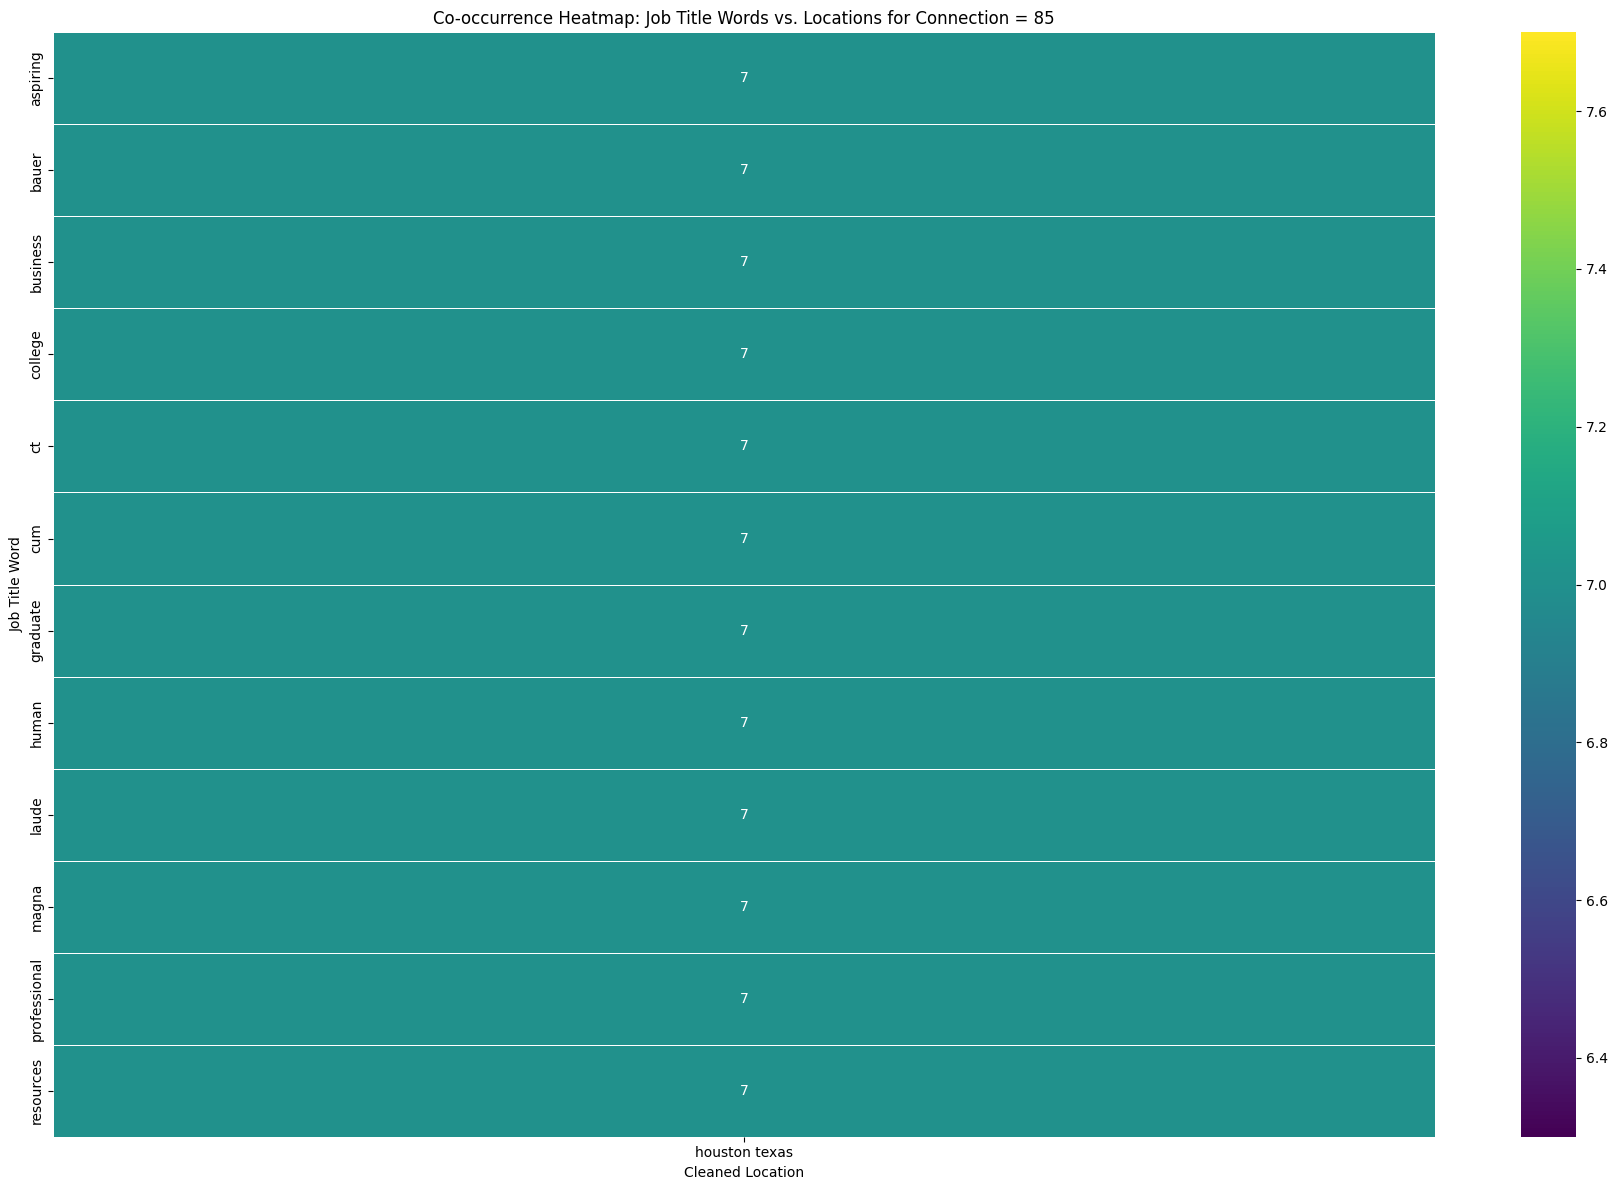

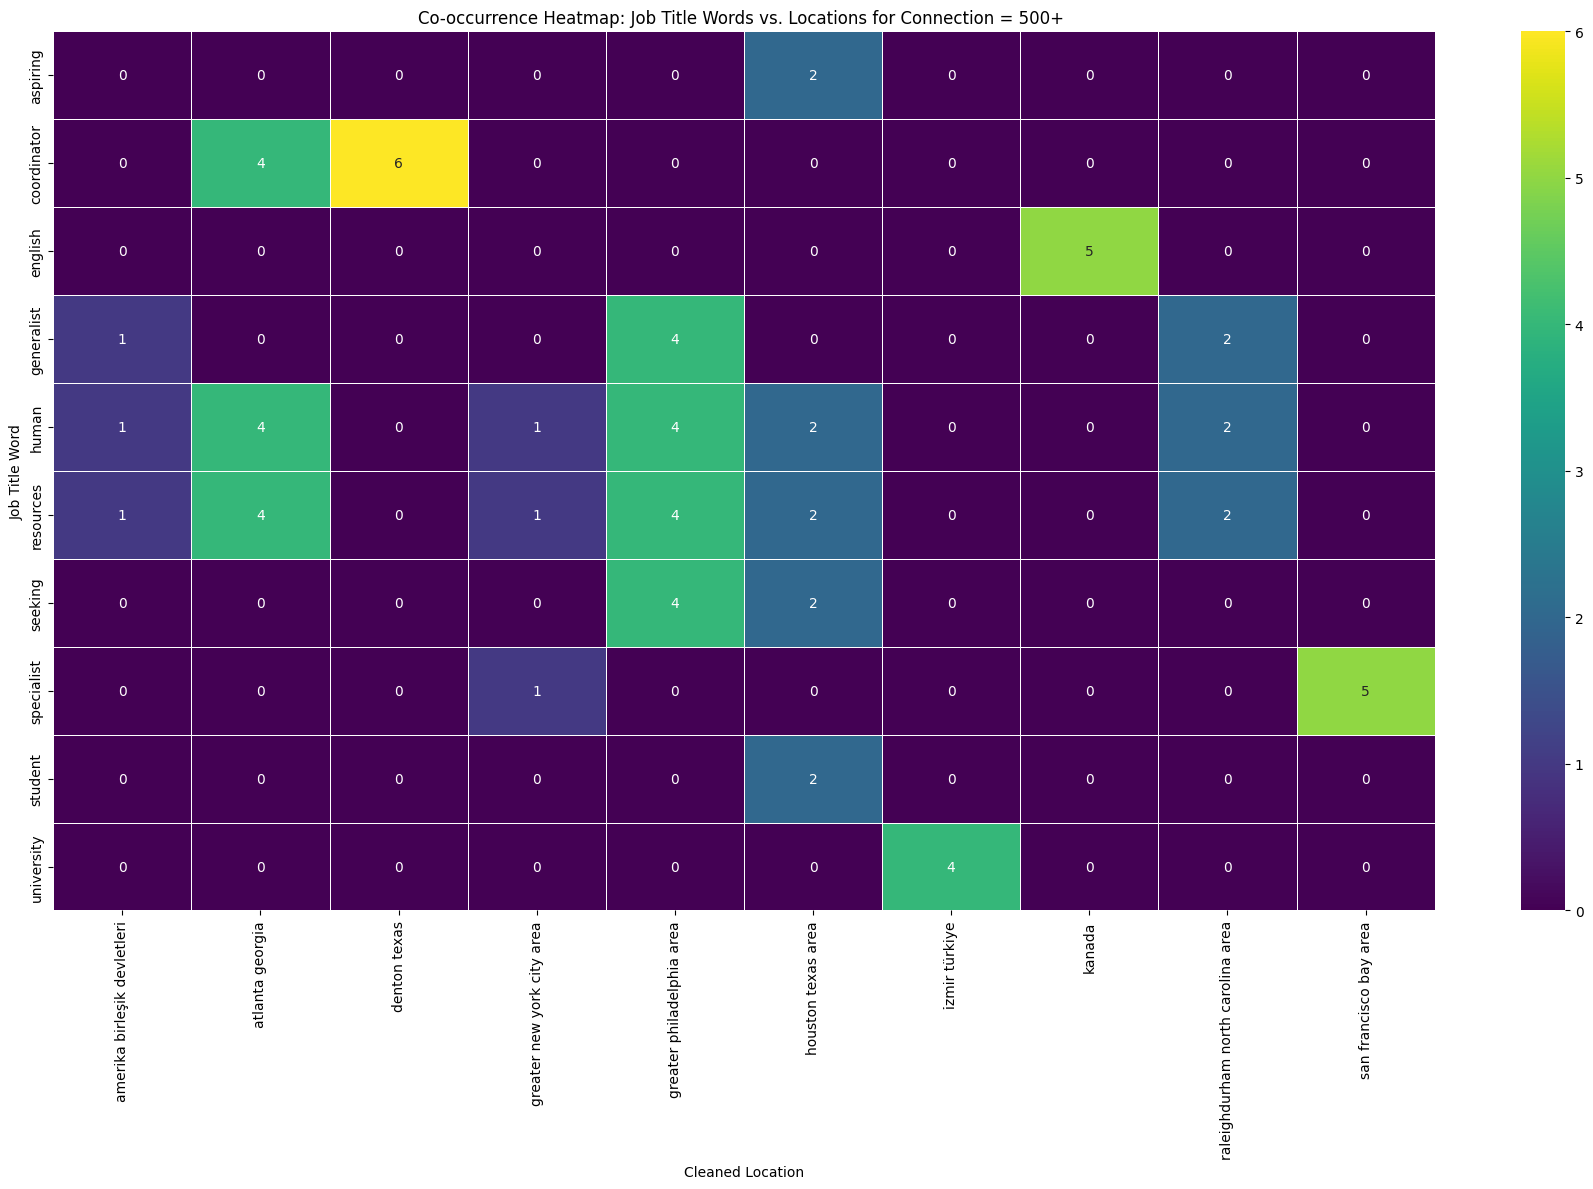

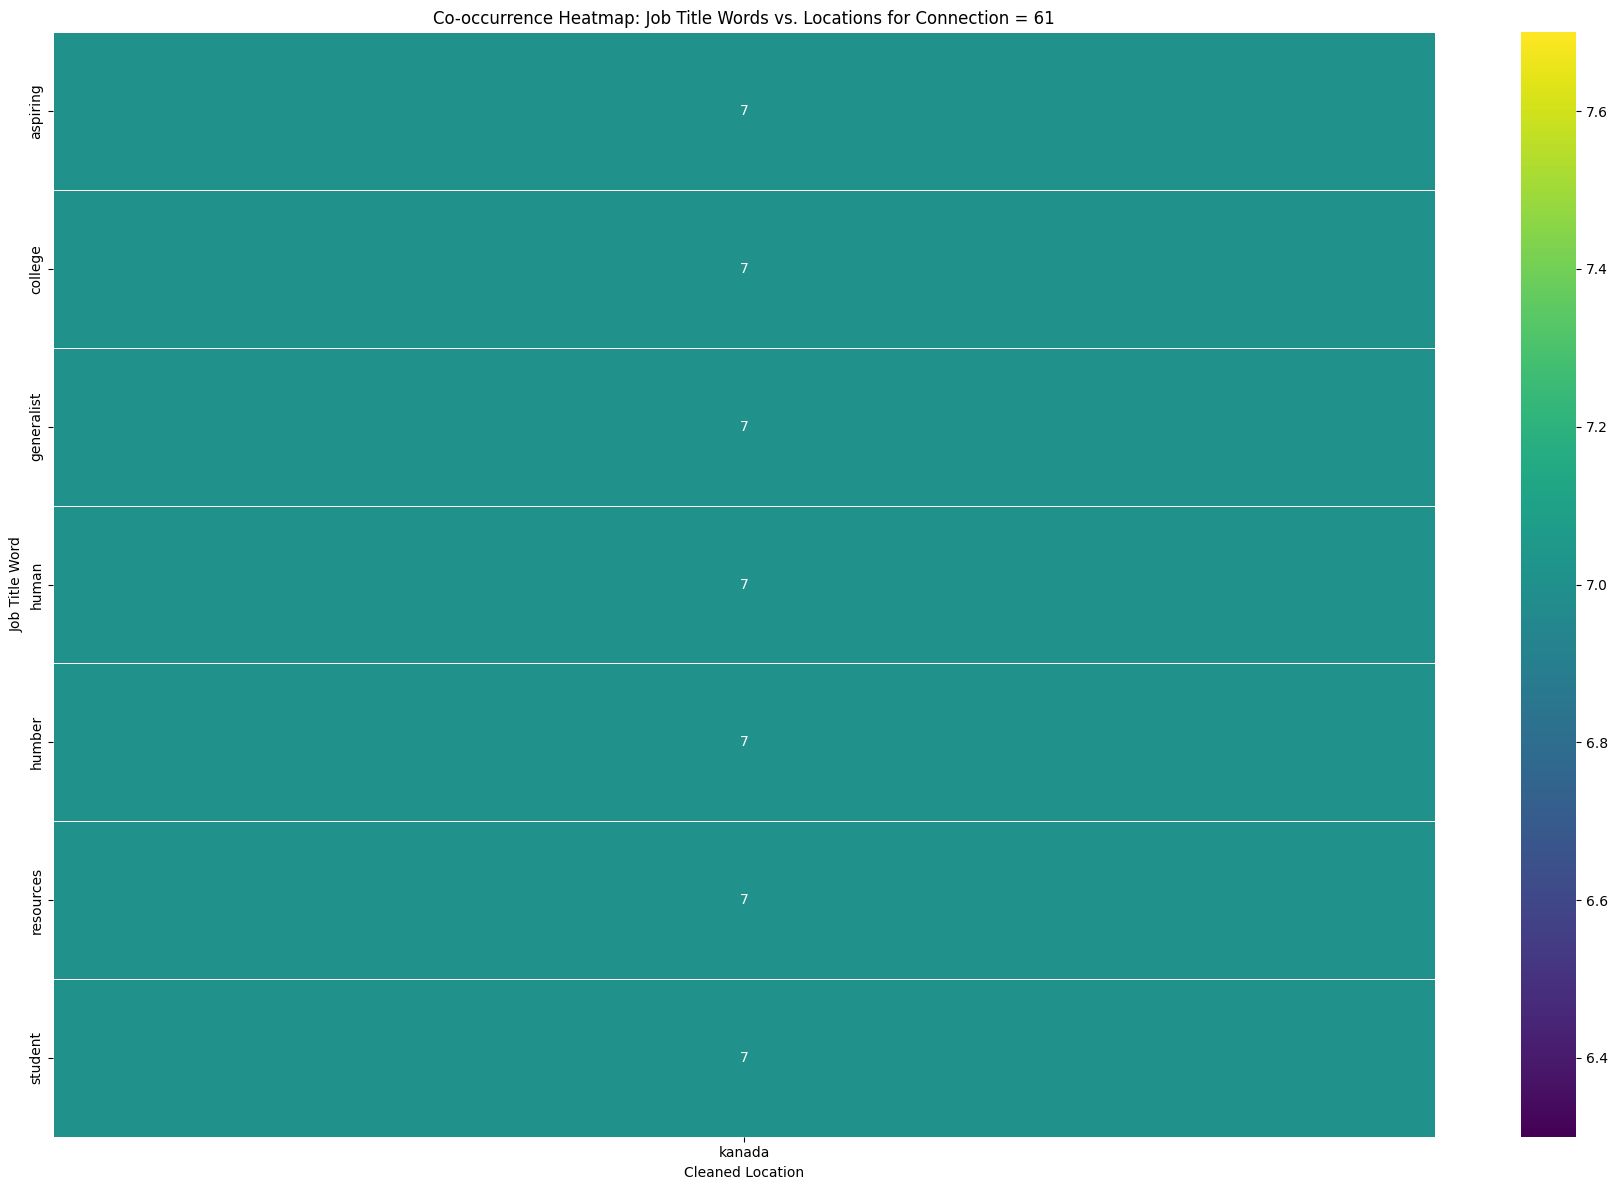

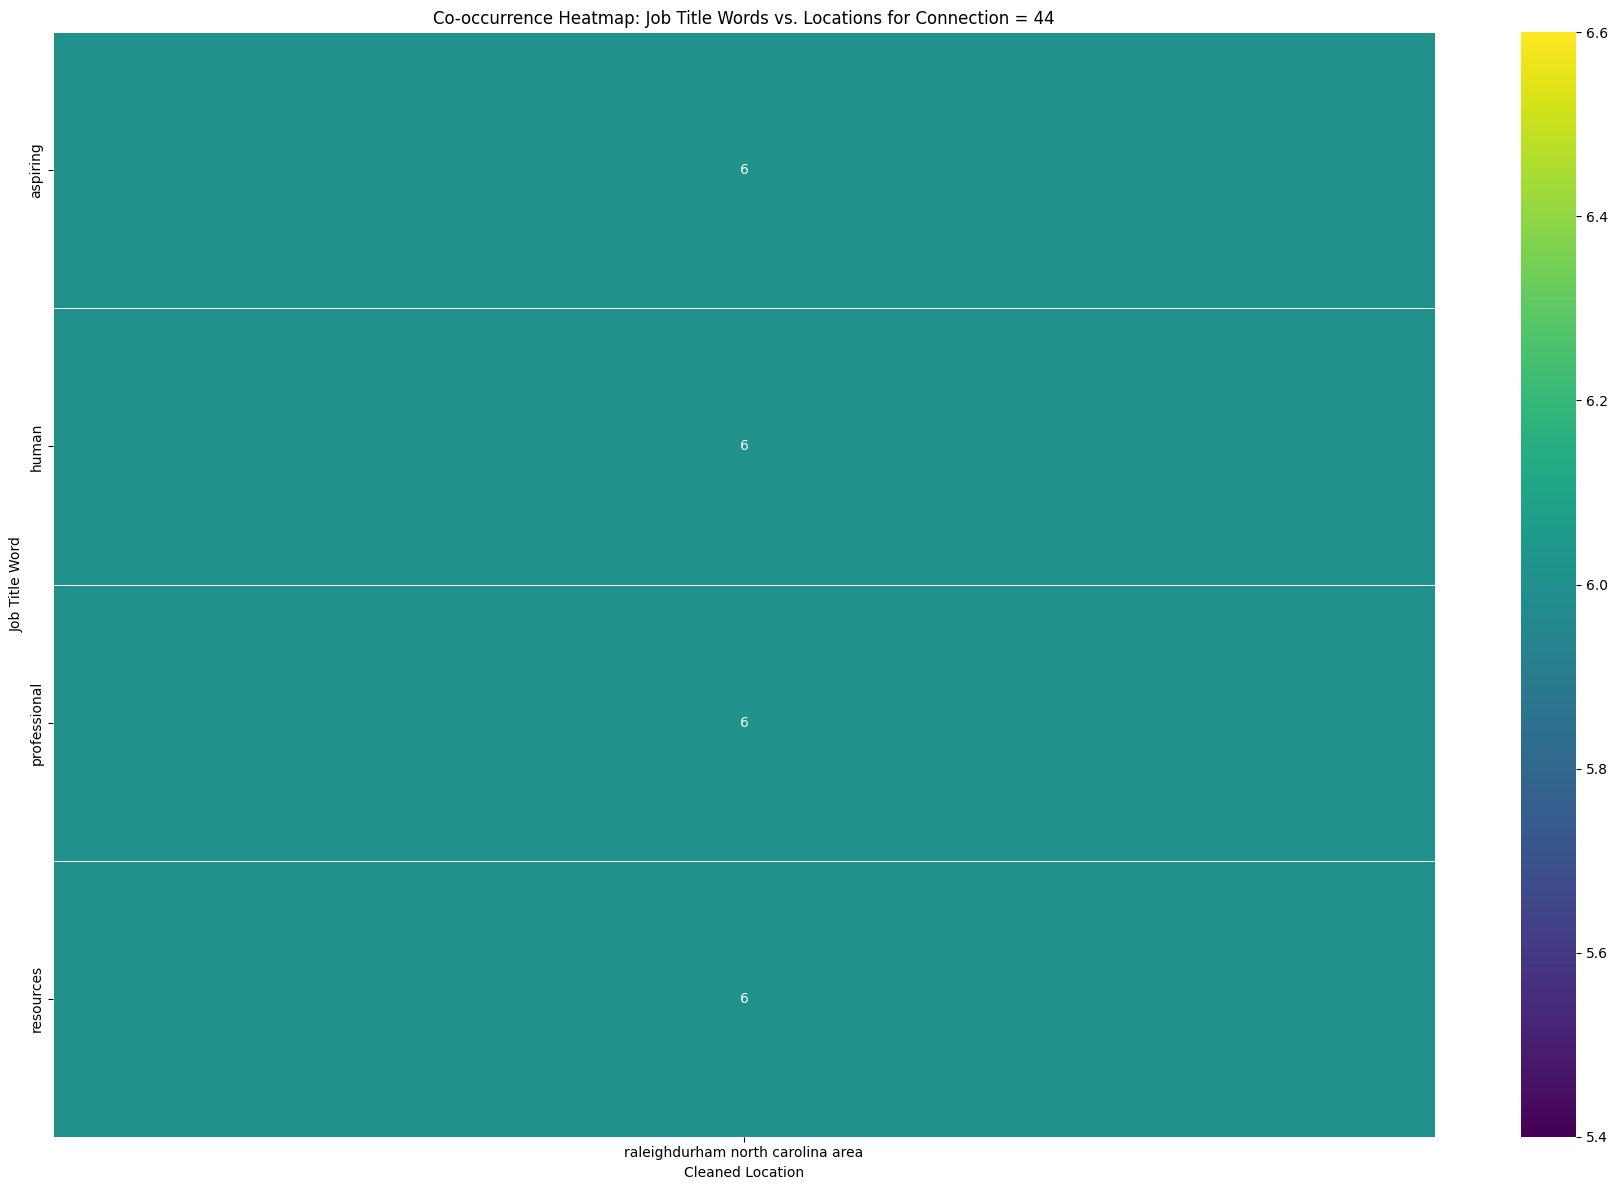

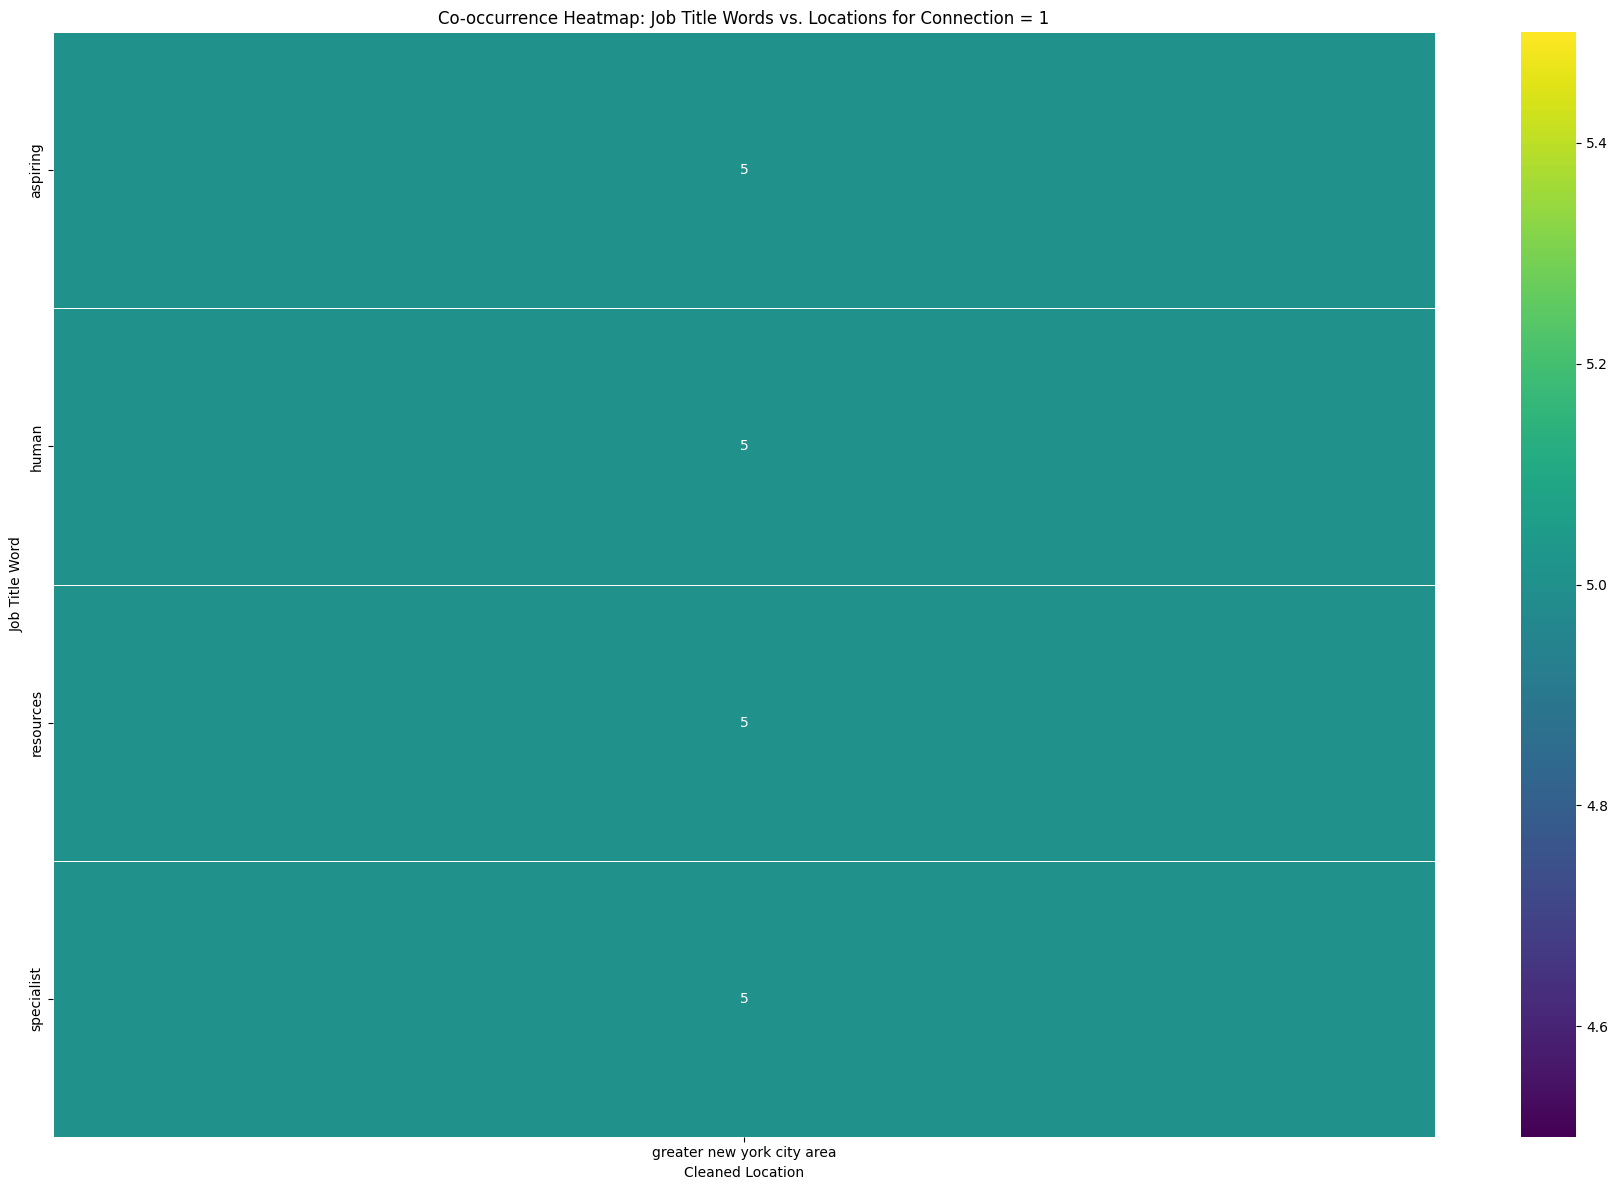

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import duckdb

# Register the pandas DataFrame as a DuckDB temporary view
duckdb_conn.register("co_occurrence_3way_view", co_occurrence_3way_df)

# Get unique connection values from the 3-way co-occurrence data using DuckDB
# We'll consider a reasonable number of top connections for plotting to avoid too many plots
# For this example, let's take the top 5 connection values by total co-occurrence count
top_5_connections_query = duckdb_conn.sql("""
    SELECT connection, SUM(co_occurrence_count) AS total_count
    FROM co_occurrence_3way_view
    GROUP BY connection
    ORDER BY total_count DESC
    LIMIT 5
""").fetchall()

top_5_connections = [row[0] for row in top_5_connections_query]

for connection_val in top_5_connections:
    # Filter the 3-way co-occurrence data for the current connection value using DuckDB
    filtered_data_query = duckdb_conn.sql(f"""
        SELECT job_title_word, cleaned_location, co_occurrence_count
        FROM co_occurrence_3way_view
        WHERE connection = '{connection_val.replace("'", "''")}'
    """)
    # Fetch the results into a pandas DataFrame
    filtered_df = filtered_data_query.fetchdf()

    # Pivot the filtered DataFrame to create a matrix for the heatmap
    # Rows: job_title_word, Columns: cleaned_location, Values: co_occurrence_count
    heatmap_data_3way = filtered_df.pivot_table(
        index='job_title_word',
        columns='cleaned_location',
        values='co_occurrence_count'
    ).fillna(0)

    # Create the heatmap
    plt.figure(figsize=(18, 12)) # Adjust figure size for better readability
    sns.heatmap(
        heatmap_data_3way,
        annot=True, # Show the co-occurrence counts on the heatmap
        fmt='g',    # Format annotations as general number
        cmap='viridis', # Color map for the heatmap
        linewidths=.5 # Add lines between cells
    )
    plt.title(f'Co-occurrence Heatmap: Job Title Words vs. Locations for Connection = {connection_val}')
    plt.xlabel('Cleaned Location')
    plt.ylabel('Job Title Word')
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

# Extra Analysis

The location data was provided as text rather than geographic coordinates (latitude and longitude). I attempted to geocode these locations using the Google Maps API. The process was unsuccessful due to API activation and billing constraints associated with the free tier.

In [ ]:
import os
import duckdb.typing
import time
import googlemaps

# --- IMPORTANT ---
# Please replace 'YOUR_GOOGLE_MAPS_API_KEY' with your actual Google Maps API Key.
# Ensure the Geocoding API is enabled for your project.
# It's recommended to store API keys securely, e.g., using environment variables or Colab secrets.
# For this example, we'll assign it directly. In a production environment, avoid hardcoding.
GOOGLE_MAPS_API_KEY = '' # @param {type:"string"}

# Initialize the Google Maps client
try:
    gmaps = googlemaps.Client(key=GOOGLE_MAPS_API_KEY)
    print("Google Maps client initialized.")
except Exception as e:
    print(f"Error initializing Google Maps client: {e}")
    print("Please ensure your API key is correct and valid.")
    # Exit if client cannot be initialized to avoid further errors
    # In a real scenario, you might want a more robust error handling strategy
    exit()

# Create a dictionary to store geocoded results to avoid redundant API calls
geocoding_cache = {}

def geocode_location(location_name):
    if location_name is None or location_name.strip() == '':
        return None, None # Return None for empty or null locations

    if location_name in geocoding_cache:
        return geocoding_cache[location_name]

    try:
        # Introduce a small delay to respect API rate limits (e.g., 50 QPS free tier)
        time.sleep(0.05) # 50ms delay, allowing roughly 20 calls per second

        geocode_result = gmaps.geocode(location_name)

        if geocode_result:
            lat = geocode_result[0]['geometry']['location']['lat']
            lng = geocode_result[0]['geometry']['location']['lng']
            geocoding_cache[location_name] = (lat, lng)
            return lat, lng
        else:
            geocoding_cache[location_name] = (None, None)
            return None, None
    except Exception as e:
        print(f"Error geocoding '{location_name}': {e}")
        geocoding_cache[location_name] = (None, None)
        return None, None

# Fetch unique cleaned locations from DuckDB directly
unique_cleaned_locations_results = duckdb_conn.sql("SELECT DISTINCT cleaned_location FROM data WHERE cleaned_location IS NOT NULL").fetchall()
unique_cleaned_locations = [row[0] for row in unique_cleaned_locations_results]

print(f"Found {len(unique_cleaned_locations)} unique cleaned locations to geocode.")

# Apply geocoding to each unique location
geocoded_results = {
    loc: geocode_location(loc) for loc in unique_cleaned_locations
}

# Prepare data for updating the DuckDB relation (avoiding pandas)
location_to_lat_lng = [
    (loc, lat, lng)
    for loc, (lat, lng) in geocoded_results.items()
]

# Create a temporary DuckDB table from the geocoded results
duckdb_conn.execute("DROP TABLE IF EXISTS geocoded_locations_temp;")
duckdb_conn.execute("""
    CREATE TABLE geocoded_locations_temp (
        cleaned_location VARCHAR,
        latitude DOUBLE,
        longitude DOUBLE
    );
""")
duckdb_conn.executemany("INSERT INTO geocoded_locations_temp VALUES (?, ?, ?);", location_to_lat_lng)

# Update the main data relation by joining with the temporary table
# First, check if latitude/longitude columns exist and exclude them to avoid duplicates
already_has_lat_lng = False
current_columns = duckdb_conn.sql("PRAGMA table_info(data)").fetchdf()
if 'latitude' in current_columns['name'].values and 'longitude' in current_columns['name'].values:
    already_has_lat_lng = True

if already_has_lat_lng:
    data = duckdb_conn.sql("""
        SELECT
            d.* EXCLUDE (latitude, longitude),
            g.latitude,
            g.longitude
        FROM
            data AS d
        LEFT JOIN
            geocoded_locations_temp AS g
        ON
            d.cleaned_location = g.cleaned_location;
    """)
else:
    data = duckdb_conn.sql("""
        SELECT
            d.*,
            g.latitude,
            g.longitude
        FROM
            data AS d
        LEFT JOIN
            geocoded_locations_temp AS g
        ON
            d.cleaned_location = g.cleaned_location;
    """)

duckdb_conn.execute("DROP TABLE geocoded_locations_temp;") # Clean up temporary table

print("DuckDB relation 'data' updated with 'latitude' and 'longitude' columns.")
print("Displaying head of the updated data:")
data.show()

Google Maps client initialized.
Found 41 unique cleaned locations to geocode.
Error geocoding 'houston texas': REQUEST_DENIED (This API is not activated on your API project. You may need to enable this API in the Google Cloud Console: https://console.cloud.google.com/apis/library?filter=category:maps. Learn more at https://developers.google.com/maps/gmp-get-started#enable-api-sdk.)
Error geocoding 'raleighdurham north carolina area': REQUEST_DENIED (This API is not activated on your API project. You may need to enable this API in the Google Cloud Console: https://console.cloud.google.com/apis/library?filter=category:maps. Learn more at https://developers.google.com/maps/gmp-get-started#enable-api-sdk.)
Error geocoding 'i̇zmir türkiye': REQUEST_DENIED (This API is not activated on your API project. You may need to enable this API in the Google Cloud Console: https://console.cloud.google.com/apis/library?filter=category:maps. Learn more at https://developers.google.com/maps/gmp-get-start

CatalogException: Catalog Error: Table with name data does not exist!
Did you mean "pg_database"?

# Conclusion

For the number of connections, entries with "500+" (max) connections were the most common, followed by entried with smaller number of conntions (less than 100).

For job titles, human resources were the most common, followed by university students and job seeking candidates.

For locations, Canada was the most common, followed by Houston, Texas and Raleigh, North Carolina, California and New York.

Canada had close relationships with aspiring, college, generalist and human resources.

Houston had close relationships with human resources, professional, magna cum laude and business and aspiring.

North Carolina had close relaitonships with humand resources, professional and aspring.

North Carolina, Texas had the closest relationships with a medium number of connections.

Texas, Canada, California had the closest relationships with 500+ connections.